In [17]:
import maboss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splrep, BSpline
from scipy.special import logit, expit
from scipy.optimize import curve_fit

In [32]:
def get_T(popstate):
    tcell = 0
    for population in popstate[1:-1].split(","):
        if len(population) > 2:
            states, pop = population[1:-1].split(":")
            if states != "<nil>":
                list_states = states.split(" -- ")
                try:
                    if "TCell" in list_states and "DC" not in list_states:
                        tcell += int(pop)
                except:
                    print(pop)
    return tcell


def get_DC(popstate):
    dc = 0
    for population in popstate[1:-1].split(","):
        if len(population) > 2:
            states, pop = population[1:-1].split(":")
            if states != "<nil>":
                list_states = states.split(" -- ")
                try:
                    if "DC" in list_states and "TCell" not in list_states:
                        dc += int(pop)
                    
                except:
                    print(pop)
    return dc



def get_TDC_ratio(popstate):
    tcell = 0
    dc = 0
    for population in popstate[1:-1].split(","):
        if len(population) > 2:
            states, pop = population[1:-1].split(":")
            if states != "<nil>":
                list_states = states.split(" -- ")
                try:
                    if "DC" in list_states and "TCell" not in list_states:
                        dc += int(pop)
                    
                    elif "TCell" in list_states:
                        tcell += int(pop)
                except:
                    print(pop)
    return None if (tcell == 0 or dc == 0) else tcell/dc

In [33]:
def cubic(list_x, a, b, c, d):
    return [a*x**3 + b*x**2 + c*x + d for x in list_x]

### Simulation with pyMaBoSS

In [34]:
sim_long = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig.cfg")
res_long = sim_long.run(workdir="ICD_phenomenological/", prefix="ResICD_phenLong")

In [35]:
sim_long5Cl = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig5CExp.cfg")
res_long5Cl = sim_long5Cl.run(workdir="ICD_phenomenological/", prefix="ResICD_phenLong5ClExp")

In [36]:
sim_long10Cl = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig10CExp.cfg")
res_long10Cl = sim_long10Cl.run(workdir="ICD_phenomenological/", prefix="ResICD_phenLong10ClExp")

In [37]:
serieT = res_long.get_state_dist_by_index(11*24+1, get_T)
serieT5Cl = res_long5Cl.get_state_dist_by_index(11*24+1, get_T)
serieT10Cl = res_long10Cl.get_state_dist_by_index(11*24+1, get_T)

In [38]:
serieDC = res_long.get_state_dist_by_index(11*24+1, get_DC)
serieDC5Cl = res_long5Cl.get_state_dist_by_index(11*24+1, get_DC)
serieDC10Cl = res_long10Cl.get_state_dist_by_index(11*24+1, get_DC)

In [44]:
serieT

0    1.0
dtype: float64

<Axes: >

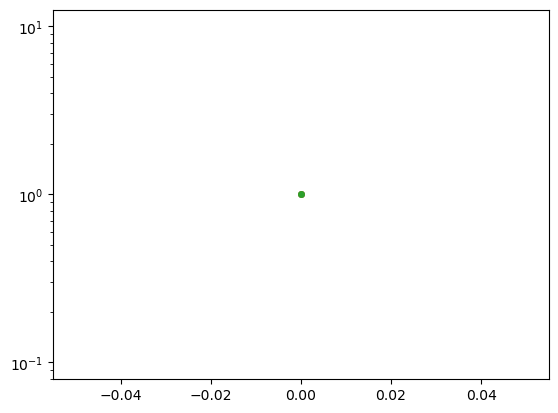

In [41]:
serieT.plot(logy=True, marker='o', markersize=4, color='C0')
serieT5Cl.plot(marker='o', markersize=4, color='C1')
serieT10Cl.plot(marker='o', markersize=4, color='C2')
# plt.legend()

In [39]:
serie = res_long.get_state_dist_by_index(11*24+1, get_TDC_ratio)
serie5Cl = res_long5Cl.get_state_dist_by_index(11*24+1, get_TDC_ratio)
serie10Cl = res_long10Cl.get_state_dist_by_index(11*24+1, get_TDC_ratio)

In [8]:
spline = splrep(serie.index, serie.values)
spline5Cl = splrep(serie5Cl.index, serie5Cl.values)
spline10Cl = splrep(serie10Cl.index, serie10Cl.values)

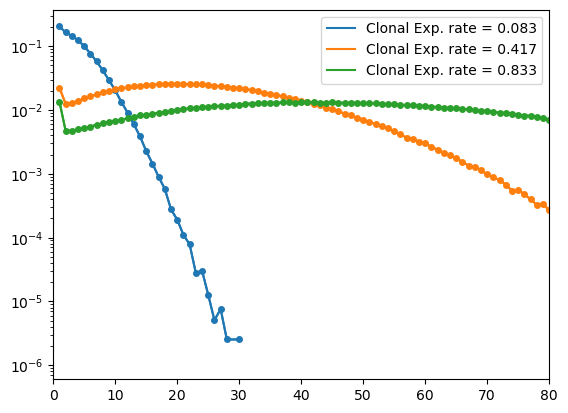

In [30]:
serie.plot(logy=True, marker='o', markersize=4, color='C0')
plt.plot(serie.index, BSpline(*spline)(serie.index), '-', color='C0', label=('Clonal Exp. rate = %.3f' % (1/12)))

serie5Cl.plot(marker='o', markersize=4, color='C1')
plt.plot(serie5Cl.index, BSpline(*spline5Cl)(serie5Cl.index), '-', color='C1', label=('Clonal Exp. rate = %.3f' % (5/12)))

serie10Cl.plot(marker='o', markersize=4, color='C2')
plt.plot(serie10Cl.index, BSpline(*spline10Cl)(serie10Cl.index), '-', color='C2', label=('Clonal Exp. rate = %.3f' % (10/12)))

plt.xlim([0,80])
plt.legend()

In [10]:
splineLogit = splrep(serie.index, logit(serie.values))
splineLogit5Cl = splrep(serie5Cl.index, logit(serie5Cl.values))
splineLogit10Cl = splrep(serie10Cl.index, logit(serie10Cl.values))

In [11]:
splineLogitFunc = BSpline(*splineLogit)
splineLogitFunc5Cl = BSpline(*splineLogit5Cl)
splineLogitFunc10Cl = BSpline(*splineLogit10Cl)

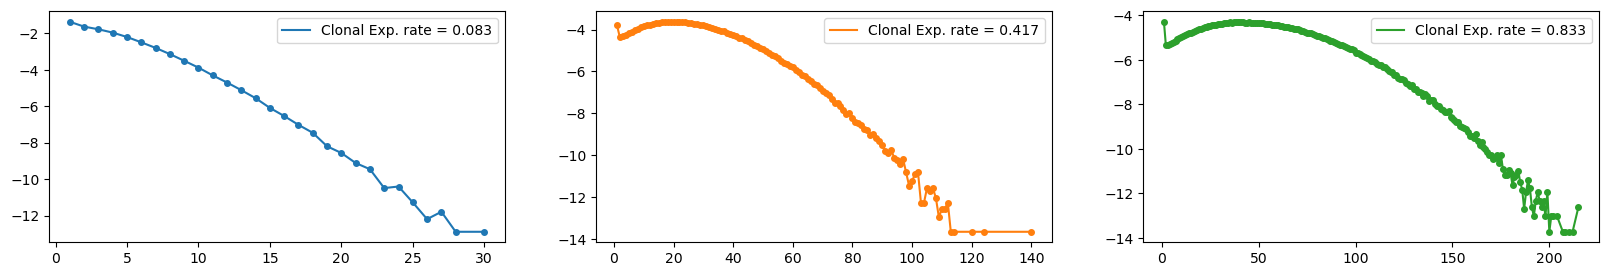

In [15]:
fig, ax = plt.subplots(1,3, figsize=(20,3))
ax[0].plot(serie.index, logit(serie.values), marker='o', markersize=4, color='C0', linestyle='None')
ax[0].plot(serie.index, splineLogitFunc(serie.index), marker=None, color='C0', label=('Clonal Exp. rate = %.3f' % (1/12)), linestyle='-')
ax[0].legend()

ax[1].plot(serie5Cl.index, logit(serie5Cl.values), marker='o', markersize=4, color='C1', linestyle='None')
ax[1].plot(serie5Cl.index, splineLogitFunc5Cl(serie5Cl.index), marker=None, color='C1', label=('Clonal Exp. rate = %.3f' % (5/12)), linestyle='-')
ax[1].legend()

ax[2].plot(serie10Cl.index, logit(serie10Cl.values), marker='o', markersize=4, color='C2', linestyle='None')
ax[2].plot(serie10Cl.index, splineLogitFunc10Cl(serie10Cl.index), marker=None, color='C2', label=('Clonal Exp. rate = %.3f' % (10/12)), linestyle='-')
ax[2].legend()

In [18]:
popt, _ = curve_fit(cubic, serie.index[1:], logit(serie.values[1:]))
popt5Cl, _ = curve_fit(cubic, serie5Cl.index[1:], logit(serie5Cl.values[1:]))
popt10Cl, _ = curve_fit(cubic, serie10Cl.index[1:], logit(serie10Cl.values[1:]))

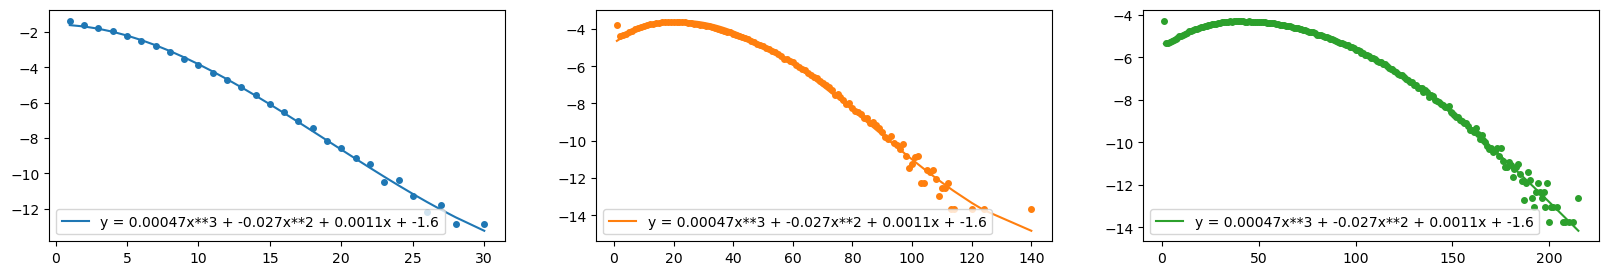

In [19]:
fig, ax = plt.subplots(1,3, figsize=(20,3))
ax[0].plot(serie.index, logit(serie.values), marker='o', markersize=4, color='C0', linestyle='None')
ax[0].plot(serie.index, cubic(serie.index, *popt), marker=None, color='C0', label=("y = %.2gx**3 + %.2gx**2 + %.2gx + %.2g" % (*popt,)), linestyle='-')
ax[0].legend()

ax[1].plot(serie5Cl.index, logit(serie5Cl.values), marker='o', markersize=4, color='C1', linestyle='None')
ax[1].plot(serie5Cl.index, cubic(serie5Cl.index, *popt5Cl), marker=None, color='C1', label=("y = %.2gx**3 + %.2gx**2 + %.2gx + %.2g" % (*popt,)), linestyle='-')
ax[1].legend()

ax[2].plot(serie10Cl.index, logit(serie10Cl.values), marker='o', markersize=4, color='C2', linestyle='None')
ax[2].plot(serie10Cl.index, cubic(serie10Cl.index, *popt10Cl), marker=None, color='C2', label=("y = %.2gx**3 + %.2gx**2 + %.2gx + %.2g" % (*popt,)), linestyle='-')
ax[2].legend()

In [20]:
exp_data = pd.read_csv("ICD_phenomenological/TratioDC.csv", sep="\t")
exp_data_filtered = exp_data[(exp_data["Day"] == 11) & (exp_data["Treatment"] == "MTX")]["TratioDC"]

In [25]:
log_likelyhood = np.log(np.prod(expit(splineLogitFunc(exp_data_filtered))))
log_likelyhood5Cl = np.log(np.prod(expit(splineLogitFunc5Cl(exp_data_filtered))))
log_likelyhood10Cl = np.log(np.prod(expit(splineLogitFunc10Cl(exp_data_filtered))))

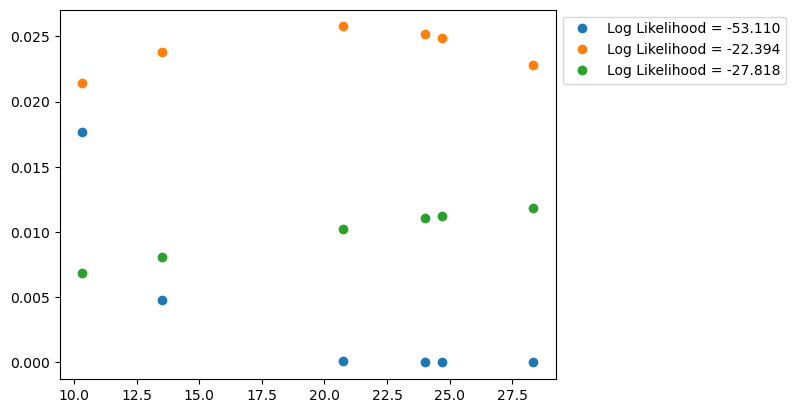

In [26]:
plt.plot(exp_data_filtered.values, expit(splineLogitFunc(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood))
plt.plot(exp_data_filtered.values, expit(splineLogitFunc5Cl(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood5Cl))
plt.plot(exp_data_filtered.values, expit(splineLogitFunc10Cl(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood10Cl))
plt.legend(loc='upper left', bbox_to_anchor=(1., 1.))

In [27]:
log_likelyhood = np.log(np.prod(expit(cubic(exp_data_filtered, *popt))))
log_likelyhood5Cl = np.log(np.prod(expit(cubic(exp_data_filtered, *popt5Cl))))
log_likelyhood10Cl = np.log(np.prod(expit(cubic(exp_data_filtered, *popt10Cl))))

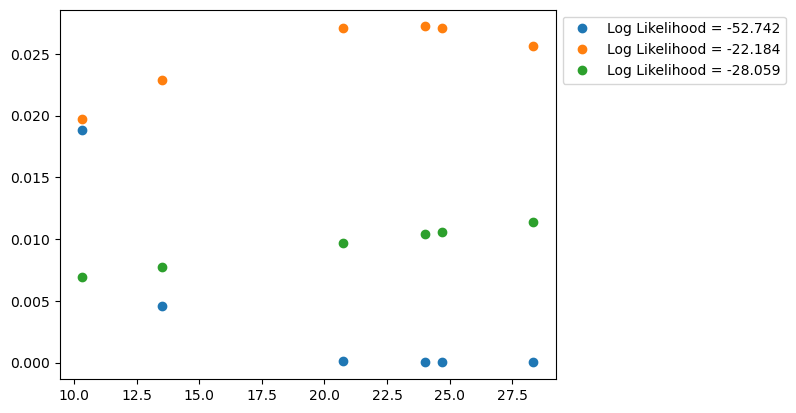

In [28]:
plt.plot(exp_data_filtered.values, expit(cubic(exp_data_filtered, *popt)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood))
plt.plot(exp_data_filtered.values, expit(cubic(exp_data_filtered, *popt5Cl)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood5Cl))
plt.plot(exp_data_filtered.values, expit(cubic(exp_data_filtered, *popt10Cl)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood10Cl))
plt.legend(loc='upper left', bbox_to_anchor=(1., 1.))

In [29]:
serie

1.0     0.203838
2.0     0.164048
3.0     0.144971
4.0     0.123814
5.0     0.099963
6.0     0.076534
7.0     0.057576
8.0     0.041632
9.0     0.029257
10.0    0.020267
11.0    0.013321
12.0    0.009044
13.0    0.005963
14.0    0.003849
15.0    0.002261
16.0    0.001448
17.0    0.000893
18.0    0.000578
19.0    0.000276
20.0    0.000191
21.0    0.000110
22.0    0.000078
23.0    0.000028
24.0    0.000030
25.0    0.000013
26.0    0.000005
27.0    0.000008
28.0    0.000003
30.0    0.000003
dtype: float64